In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Configuración
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("=" * 80)
print("CHURN PREDICTION - DATA PREPROCESSING")
print("=" * 80)

# Cargar dataset
df = pd.read_csv('../data/raw/Churn_Modelling.csv')
print(f"\nDataset original: {df.shape}")
print(df.head())

CHURN PREDICTION - DATA PREPROCESSING

Dataset original: (10000, 14)
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2 

In [4]:
print("\n1. ELIMINAR COLUMNAS NO ÚTILES")
print("\nColumnas originales:")
print(df.columns.tolist())

# Eliminar columnas que no aportan valor
columns_to_drop = ['RowNumber', 'CustomerId', 'Surname']
df = df.drop(columns=columns_to_drop)

print(f"\nColumnas después de eliminar: {df.columns.tolist()}")
print(f"Shape: {df.shape}")


1. ELIMINAR COLUMNAS NO ÚTILES

Columnas originales:
['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Columnas después de eliminar: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
Shape: (10000, 11)


In [5]:
print("\n2. VERIFICAR MISSING VALUES")
missing = df.isnull().sum()
print(f"Missing values:\n{missing}")
if missing.sum() == 0:
    print("✅ No hay valores faltantes")


2. VERIFICAR MISSING VALUES
Missing values:
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64
✅ No hay valores faltantes


In [7]:
print("\n3. IDENTIFICAR TIPOS DE VARIABLES")

# Identificar columnas categóricas y numéricas
categorical_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remover target de numéricas
if 'Exited' in numerical_cols:
    numerical_cols.remove('Exited')

print(f"\nCategorical columns: {categorical_cols}")
print(f"Numerical columns: {numerical_cols}")

# Ver unique values de categóricas
print("\nUnique values por columna categórica:")
for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")


3. IDENTIFICAR TIPOS DE VARIABLES

Categorical columns: ['Geography', 'Gender']
Numerical columns: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

Unique values por columna categórica:
Geography: <StringArray>
['France', 'Spain', 'Germany']
Length: 3, dtype: str
Gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str


In [8]:
print("\n4. ENCODING DE VARIABLES CATEGÓRICAS")

df_processed = df.copy()

# Para Geography: One-Hot Encoding
print("\nAntes de encoding Geography:")
print(df_processed['Geography'].value_counts())

df_processed = pd.get_dummies(df_processed, columns=['Geography'], drop_first=True)

print("\nDespués de One-Hot Encoding Geography:")
print([col for col in df_processed.columns if 'Geography' in col])

# Para Gender: Label Encoding (0=Female, 1=Male)
gender_mapping = {'Female': 0, 'Male': 1}
df_processed['Gender'] = df_processed['Gender'].map(gender_mapping)

print(f"\nGender mapeado: {df_processed['Gender'].unique()}")
print(f"\nDataset después de encoding: {df_processed.shape}")
print(df_processed.head())


4. ENCODING DE VARIABLES CATEGÓRICAS

Antes de encoding Geography:
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Después de One-Hot Encoding Geography:
['Geography_Germany', 'Geography_Spain']

Gender mapeado: [0 1]

Dataset después de encoding: (10000, 12)
   CreditScore  Gender  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619       0   42       2       0.00              1          1   
1          608       0   41       1   83807.86              1          0   
2          502       0   42       8  159660.80              3          1   
3          699       0   39       1       0.00              2          0   
4          850       0   43       2  125510.82              1          1   

   IsActiveMember  EstimatedSalary  Exited  Geography_Germany  Geography_Spain  
0               1        101348.88       1              False            False  
1               1        112542.58       0              False             True  
2 


5. ANÁLISIS DE OUTLIERS

Estadísticas de variables numéricas:
        CreditScore           Age        Tenure        Balance  NumOfProducts  \
count  10000.000000  10000.000000  10000.000000   10000.000000   10000.000000   
mean     650.528800     38.921800      5.012800   76485.889288       1.530200   
std       96.653299     10.487806      2.892174   62397.405202       0.581654   
min      350.000000     18.000000      0.000000       0.000000       1.000000   
25%      584.000000     32.000000      3.000000       0.000000       1.000000   
50%      652.000000     37.000000      5.000000   97198.540000       1.000000   
75%      718.000000     44.000000      7.000000  127644.240000       2.000000   
max      850.000000     92.000000     10.000000  250898.090000       4.000000   

         HasCrCard  IsActiveMember  EstimatedSalary  
count  10000.00000    10000.000000     10000.000000  
mean       0.70550        0.515100    100090.239881  
std        0.45584        0.499797     57510.

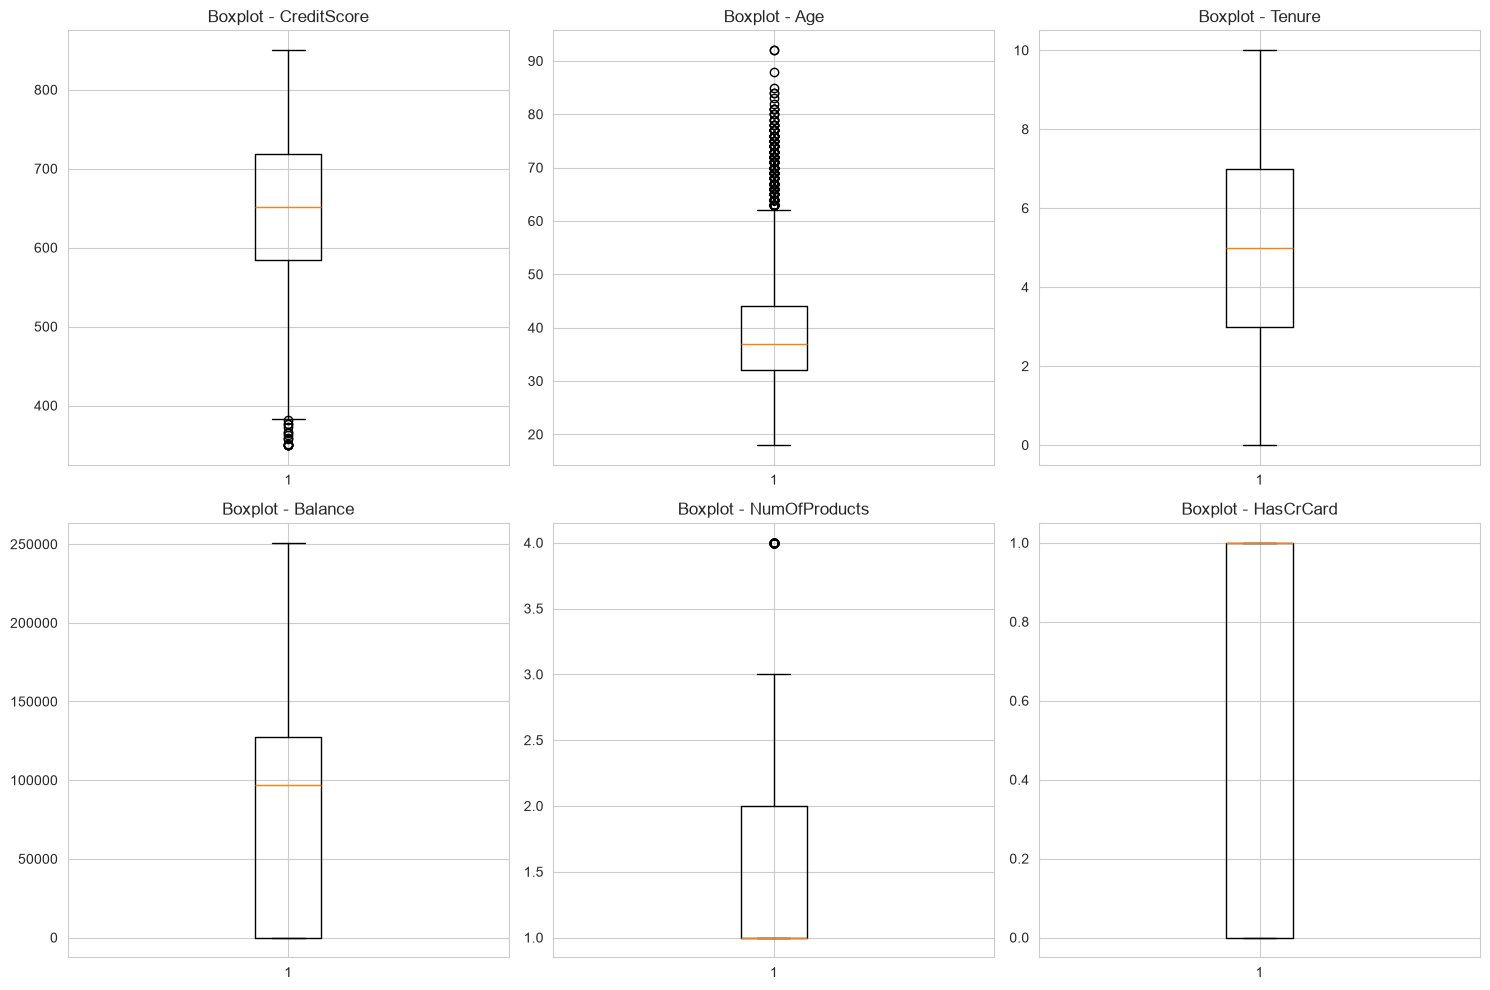

Nota: Los outliers pueden ser valores reales, no necesariamente errores


In [9]:
print("\n5. ANÁLISIS DE OUTLIERS")

# Ver distribución de variables numéricas
print("\nEstadísticas de variables numéricas:")
print(df_processed[numerical_cols].describe())

# Visualizar outliers con boxplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    if idx < len(axes):
        axes[idx].boxplot(df_processed[col])
        axes[idx].set_title(f'Boxplot - {col}')

plt.tight_layout()
plt.show()

print("Nota: Los outliers pueden ser valores reales, no necesariamente errores")

In [10]:
print("\n6. NORMALIZACIÓN DE VARIABLES NUMÉRICAS")

# Crear copia para escalado
df_scaled = df_processed.copy()

# Escalador StandardScaler (media=0, desviación=1)
scaler = StandardScaler()

# Aplicar escalado solo a variables numéricas
df_scaled[numerical_cols] = scaler.fit_transform(df_processed[numerical_cols])

print("\nAntes de escalado (primeras filas):")
print(df_processed[numerical_cols].head())

print("\nDespués de escalado (primeras filas):")
print(df_scaled[numerical_cols].head())

print("\nMean después de escalado (debe ser ~0):")
print(df_scaled[numerical_cols].mean())


6. NORMALIZACIÓN DE VARIABLES NUMÉRICAS

Antes de escalado (primeras filas):
   CreditScore  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619   42       2       0.00              1          1   
1          608   41       1   83807.86              1          0   
2          502   42       8  159660.80              3          1   
3          699   39       1       0.00              2          0   
4          850   43       2  125510.82              1          1   

   IsActiveMember  EstimatedSalary  
0               1        101348.88  
1               1        112542.58  
2               0        113931.57  
3               0         93826.63  
4               1         79084.10  

Después de escalado (primeras filas):
   CreditScore       Age    Tenure   Balance  NumOfProducts  HasCrCard  \
0    -0.326221  0.293517 -1.041760 -1.225848      -0.911583   0.646092   
1    -0.440036  0.198164 -1.387538  0.117350      -0.911583  -1.547768   
2    -1.536794  0.293517  1.03


7. ANÁLISIS DE DESBALANCE DE CLASES

Distribución de target (Exited):
Exited
0    7963
1    2037
Name: count, dtype: int64

Tasa de churn: 20.37%
Ratio: 7963 / 2037


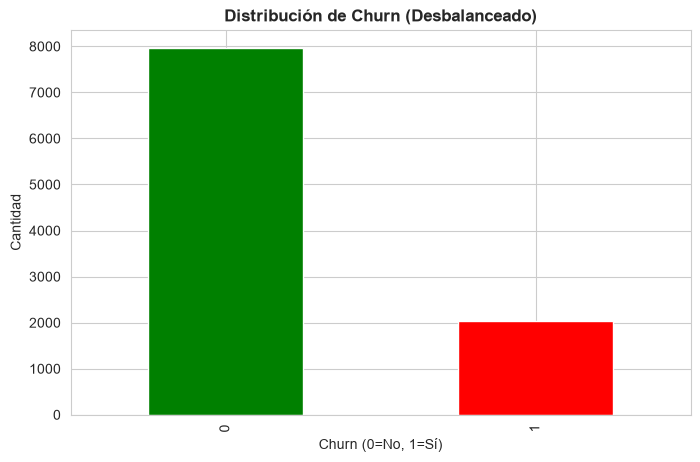


⚠️  Nota: Las clases están desbalanceadas. Usaremos SMOTE para balancear.


In [11]:
print("\n7. ANÁLISIS DE DESBALANCE DE CLASES")

print(f"\nDistribución de target (Exited):")
print(df_scaled['Exited'].value_counts())

churn_rate = (df_scaled['Exited'].sum() / len(df_scaled)) * 100
print(f"\nTasa de churn: {churn_rate:.2f}%")
print(f"Ratio: {df_scaled['Exited'].value_counts()[0]} / {df_scaled['Exited'].value_counts()[1]}")

# Gráfico
fig, ax = plt.subplots(figsize=(8, 5))
df_scaled['Exited'].value_counts().plot(kind='bar', ax=ax, color=['green', 'red'])
ax.set_title('Distribución de Churn (Desbalanceado)', fontsize=12, fontweight='bold')
ax.set_xlabel('Churn (0=No, 1=Sí)')
ax.set_ylabel('Cantidad')
plt.show()

print("\n⚠️  Nota: Las clases están desbalanceadas. Usaremos SMOTE para balancear.")

In [12]:
print("\n8. SPLIT DE DATOS")

# Separar features y target
X = df_scaled.drop('Exited', axis=1)
y = df_scaled['Exited']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Primer split: 80% train+val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Segundo split: del 80%, 75% train (60% total), 25% val (20% total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"\nTrain set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")

print(f"\nDistribución en train: {y_train.value_counts().to_dict()}")
print(f"Distribución en val: {y_val.value_counts().to_dict()}")
print(f"Distribución en test: {y_test.value_counts().to_dict()}")


8. SPLIT DE DATOS

Features shape: (10000, 11)
Target shape: (10000,)

Train set: (6000, 11)
Validation set: (2000, 11)
Test set: (2000, 11)

Distribución en train: {0: 4777, 1: 1223}
Distribución en val: {0: 1593, 1: 407}
Distribución en test: {0: 1593, 1: 407}


In [13]:
print("\n9. APLICAR SMOTE (BALANCEAR DATASET DE TRAINING)")

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"\nTrain set ANTES de SMOTE:")
print(y_train.value_counts())
print(f"Shape: {X_train.shape}")

print(f"\nTrain set DESPUÉS de SMOTE:")
print(y_train_smote.value_counts())
print(f"Shape: {X_train_smote.shape}")

print("\n✅ Las clases están balanceadas en el set de training")


9. APLICAR SMOTE (BALANCEAR DATASET DE TRAINING)

Train set ANTES de SMOTE:
Exited
0    4777
1    1223
Name: count, dtype: int64
Shape: (6000, 11)

Train set DESPUÉS de SMOTE:
Exited
0    4777
1    4777
Name: count, dtype: int64
Shape: (9554, 11)

✅ Las clases están balanceadas en el set de training


In [14]:
print("\n10. GUARDAR DATOS PROCESADOS")

# Crear DataFrames finales
train_data = pd.concat([
    pd.DataFrame(X_train_smote, columns=X.columns).reset_index(drop=True),
    pd.Series(y_train_smote, name='Exited').reset_index(drop=True)
], axis=1)

val_data = pd.concat([
    X_val.reset_index(drop=True),
    y_val.reset_index(drop=True)
], axis=1)

test_data = pd.concat([
    X_test.reset_index(drop=True),
    y_test.reset_index(drop=True)
], axis=1)

# Guardar en CSV
train_data.to_csv('../data/processed/train_data.csv', index=False)
val_data.to_csv('../data/processed/val_data.csv', index=False)
test_data.to_csv('../data/processed/test_data.csv', index=False)

print("✅ Datos guardados en:")
print(f"   - ../data/processed/train_data.csv")
print(f"   - ../data/processed/val_data.csv")
print(f"   - ../data/processed/test_data.csv")

print(f"\nTrain: {train_data.shape}")
print(f"Validation: {val_data.shape}")
print(f"Test: {test_data.shape}")


10. GUARDAR DATOS PROCESADOS
✅ Datos guardados en:
   - ../data/processed/train_data.csv
   - ../data/processed/val_data.csv
   - ../data/processed/test_data.csv

Train: (9554, 12)
Validation: (2000, 12)
Test: (2000, 12)


In [15]:
print("\n" + "=" * 80)
print("RESUMEN DE PREPROCESSING")
print("=" * 80)

print(f"\n✅ Datos limpios")
print(f"✅ Variables categóricas codificadas")
print(f"✅ Variables numéricas escaladas")
print(f"✅ Desbalance manejado con SMOTE")
print(f"✅ Dataset dividido en train/val/test")
print(f"\nDataset listo para modelado 🚀")


RESUMEN DE PREPROCESSING

✅ Datos limpios
✅ Variables categóricas codificadas
✅ Variables numéricas escaladas
✅ Desbalance manejado con SMOTE
✅ Dataset dividido en train/val/test

Dataset listo para modelado 🚀
